In [12]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from ripplegw.waveforms.IMRPhenomXP import gen_IMRPhenomXP_hphc
from ripplegw.waveforms.IMRPhenomXPHM import DEV_generate_xphm_xhm
from ripplegw.conversions import ms_to_Mc_eta
from ripplegw.constants import MSUN, MTSUN
from utils import get_freqs
import lal
import lalsimulation as lalsim

In [13]:
def get_lal_XP(f, theta, f_ref):
    m1_kg = float(theta[0]) * lal.MSUN_SI
    m2_kg = float(theta[1]) * lal.MSUN_SI
    s1x, s1y, s1z = float(theta[2]), float(theta[3]), float(theta[4])
    s2x, s2y, s2z = float(theta[5]), float(theta[6]), float(theta[7])
    distance = float(theta[8]) * 1e6 * lal.PC_SI
    phi_ref = float(theta[10])
    inclination = float(theta[11])

    f_l = f[0]
    f_u = f[-1]
    df = f[1] - f[0]

    approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomXP")

    def _make_xp_params(prec_version):
        p = lal.CreateDict()
        lalsim.SimInspiralWaveformParamsInsertPhenomXPrecVersion(p, prec_version)
        return p

    def _call_xp(lalparams):
        return lalsim.SimInspiralChooseFDWaveform(
                        m1_kg,
                        m2_kg,
                        s1x,
                        s1y,
                        s1z,
                        s2x,
                        s2y,
                        s2z,
                        distance,
                        inclination,
                        phi_ref,
                        0,
                        0,
                        0,
                        df,
                        f_l,
                        f_u,
                        f_ref,
                        lalparams,
                        approximant
                    )   

    # Use PrecVersion=222: identical to 223 (same MSA expressions from
    # LALSimInspiralFDPrecAngles, same PN coefficients L3/L5) but raises a
    # terminal error on MSA init failure instead of silently falling back to
    # NNLO angles.  The caller detects the exception and excludes the sample
    # from the mismatch assertion and histogram.
    hp_lal_full, hc_lal_full = _call_xp(_make_xp_params(222))
    hp_lal_full, hc_lal_full = hp_lal_full.data.data, hc_lal_full.data.data
    
    # Extract the waveform data and mask to the frequency range (same as test suite)
    freqs_lal = np.arange(len(hp_lal_full)) * df
    mask_lal = (freqs_lal >= f_l) & (freqs_lal <= f_u)
    hp_lalsuite = hp_lal_full[mask_lal]
    hc_lalsuite = hc_lal_full[mask_lal]
    
    return hp_lalsuite, hc_lalsuite


In [14]:
m1 = 30.0
m2 = 20.0
s1x, s1y, s1z = 0.7, 0.0, 0.3
s2x, s2y, s2z = -0.0, -0.0, -0.6
distance = 500.0
phi_ref = 0.0
inclination = 0.0

# Generate frequency grid using FFT-compatible method (same as test suite)
f_l = 20.0
f_u = 1024.0
f_sampling = 2 * f_u  # Nyquist criterion
T = 4.0  # Duration in seconds

f = get_freqs(f_l, f_u, f_sampling, T)

mc, eta = ms_to_Mc_eta((m1, m2))

theta_lal = jnp.array([m1, m2, s1x, s1y, s1z, s2x, s2y, s2z, distance, 0.0, phi_ref, inclination])
theta_ripple = jnp.array([mc, eta, s1x, s1y, s1z, s2x, s2y, s2z, distance, 0.0, phi_ref, inclination])
f_ref = 20.0

hp_lal, hc_lal = get_lal_XP(np.array(f), theta_lal, f_ref)
hp_ripple, hc_ripple = gen_IMRPhenomXP_hphc(f, theta_ripple, f_ref)

hp_ripple_xphm, hc_ripple_xphm = DEV_generate_xphm_xhm(f, theta_lal, f_ref)

/home/robinc/jax_gw/ripple/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/robinc/jax_gw/ripple/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


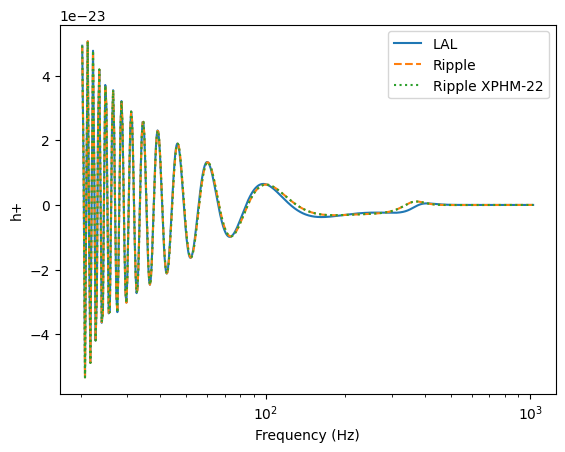

In [15]:
plt.plot(f, hp_lal, label="LAL")
plt.plot(f, hp_ripple, label="Ripple", ls='--')
plt.plot(f, hp_ripple_xphm, label="Ripple XPHM-22", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("h+")
plt.xscale("log")
plt.legend()
plt.show()

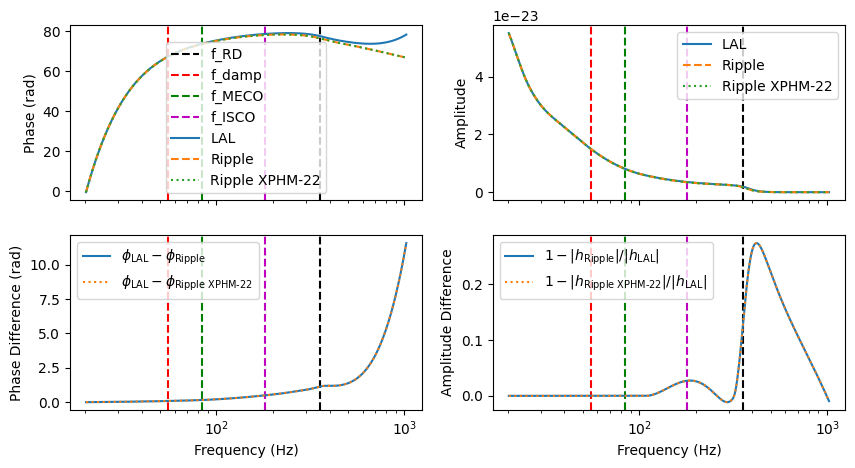

In [16]:
from ripplegw.waveforms import IMRPhenomX_utils
ripple_phase = np.unwrap(np.angle(hp_ripple))
lal_phase = np.unwrap(np.angle(hp_lal))
ripple_xphm22_phase = np.unwrap(np.angle(hp_ripple_xphm))

ripple_amp = np.abs(hp_ripple)
lal_amp = np.abs(hp_lal)

fRD, fdamp, fMECO, fISCO = np.array(IMRPhenomX_utils.get_cutoff_fMs(m1, m2, s1z, s2z)) / ((m1 + m2) * MTSUN)

fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharex=True)

axs[0, 0].axvline(fRD, color='k', ls='--', label='f_RD')
axs[0, 0].axvline(fdamp, color='r', ls='--', label='f_damp')
axs[0, 0].axvline(fMECO, color='g', ls='--', label='f_MECO')
axs[0, 0].axvline(fISCO, color='m', ls='--', label='f_ISCO')

for ax in axs.flat[1:]:
    ax.axvline(fRD, color='k', ls='--')
    ax.axvline(fdamp, color='r', ls='--')
    ax.axvline(fMECO, color='g', ls='--')
    ax.axvline(fISCO, color='m', ls='--')

axs[0, 0].plot(f, lal_phase, label="LAL")
axs[0, 0].plot(f, ripple_phase, label="Ripple", ls='--')
axs[0, 0].plot(f, ripple_xphm22_phase, label="Ripple XPHM-22", ls=':')
axs[0, 0].set_ylabel("Phase (rad)")
axs[0, 0].legend()
axs[1, 0].plot(f, lal_phase - ripple_phase, label=r"$\phi_{\text{LAL}} - \phi_{\text{Ripple}}$")
axs[1, 0].plot(f, lal_phase - ripple_xphm22_phase, label=r"$\phi_{\text{LAL}} - \phi_{\text{Ripple XPHM-22}}$", ls=':')
axs[1, 0].set_xlabel("Frequency (Hz)")
axs[1, 0].set_ylabel("Phase Difference (rad)")
axs[1, 0].set_xscale("log")
axs[1, 0].legend()

axs[0, 1].plot(f, lal_amp, label="LAL")
axs[0, 1].plot(f, ripple_amp, label="Ripple", ls='--')
axs[0, 1].plot(f, np.abs(hp_ripple_xphm), label="Ripple XPHM-22", ls=':')
axs[0, 1].set_ylabel("Amplitude")
axs[0, 1].legend()
axs[1, 1].plot(f, (lal_amp - ripple_amp)/lal_amp, label=r"$1 - |h_{\text{Ripple}}|/|h_{\text{LAL}}|$")
axs[1, 1].plot(f, (lal_amp - np.abs(hp_ripple_xphm))/lal_amp, label=r"$1 - |h_{\text{Ripple XPHM-22}}|/|h_{\text{LAL}}|$", ls=':')
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_ylabel("Amplitude Difference")
axs[1, 1].set_xscale("log")
axs[1, 1].legend()
plt.show()

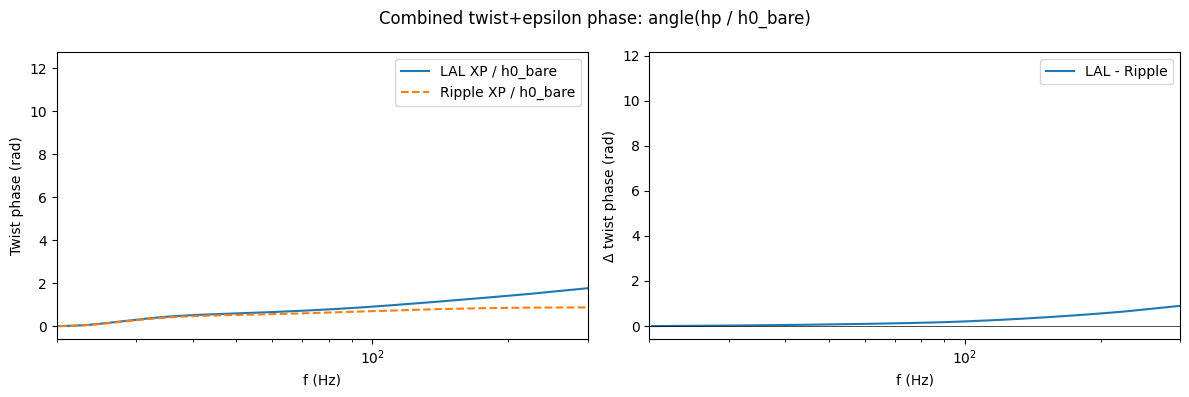

Twist phase diff at f=20 Hz: 0.000000 rad
Twist phase diff at f=50 Hz:  0.072798 rad
Twist phase diff at f=100 Hz: 0.207166 rad
Twist phase diff at f=200 Hz: 0.559491 rad
Slope (20-50 Hz): 0.002427 rad/Hz


In [8]:

# Diagnostic 1: Extract the combined twist phase (2*alpha - 2*eps) from both waveforms
# by dividing out the co-precessing h0_bare.
# At small theta_JN (face-on), hp ≈ h0_bare * e^{2i*alpha} * cBetah^4 * conj(Y22) * e^{-2i*eps}/2
# so angle(hp/h0_bare) ≈ 2*alpha - 2*eps + const

from ripplegw.waveforms.IMRPhenomXAS import gen_IMRPhenomXAS
from ripplegw.constants import PI, MTSUN

theta_XAS_diag = jnp.array([mc, eta, s1z, s2z, distance, 0.0, phi_ref])
h0_XAS_diag = gen_IMRPhenomXAS(f, theta_XAS_diag, f_ref)
h0_bare_diag = h0_XAS_diag * jnp.exp(-1j * PI) / (2.0 * jnp.sqrt(5.0 / (64.0 * PI)))

h0_bare_np = np.array(h0_bare_diag)
hp_lal_np = np.array(hp_lal)
hp_rip_np = np.array(hp_ripple)

# Ratio waveform / co-precessing mode → pure twist+epsilon contribution
ratio_lal = hp_lal_np / h0_bare_np
ratio_rip = hp_rip_np / h0_bare_np

twist_phase_lal = np.unwrap(np.angle(ratio_lal))
twist_phase_rip = np.unwrap(np.angle(ratio_rip))

# Zero both at f_ref
i_ref = np.argmin(np.abs(f - f_ref))
twist_phase_lal -= twist_phase_lal[i_ref]
twist_phase_rip -= twist_phase_rip[i_ref]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(f, twist_phase_lal, label='LAL XP / h0_bare')
axs[0].plot(f, twist_phase_rip, label='Ripple XP / h0_bare', ls='--')
axs[0].set_xlabel('f (Hz)'); axs[0].set_ylabel('Twist phase (rad)')
axs[0].set_xscale('log'); axs[0].legend(); axs[0].set_xlim([20, 300])

diff = twist_phase_lal - twist_phase_rip
axs[1].plot(f, diff, label='LAL - Ripple')
axs[1].axhline(0, color='k', lw=0.5)
axs[1].set_xlabel('f (Hz)'); axs[1].set_ylabel('Δ twist phase (rad)')
axs[1].set_xscale('log'); axs[1].legend(); axs[1].set_xlim([20, 300])
plt.suptitle('Combined twist+epsilon phase: angle(hp / h0_bare)')
plt.tight_layout()
plt.show()

print(f"Twist phase diff at f=20 Hz: {diff[i_ref]:.6f} rad")
i_50 = np.argmin(np.abs(f - 50))
i_100 = np.argmin(np.abs(f - 100))
i_200 = np.argmin(np.abs(f - 200))
print(f"Twist phase diff at f=50 Hz:  {diff[i_50]:.6f} rad")
print(f"Twist phase diff at f=100 Hz: {diff[i_100]:.6f} rad")
print(f"Twist phase diff at f=200 Hz: {diff[i_200]:.6f} rad")
print(f"Slope (20-50 Hz): {(diff[i_50] - diff[i_ref])/(50-20):.6f} rad/Hz")


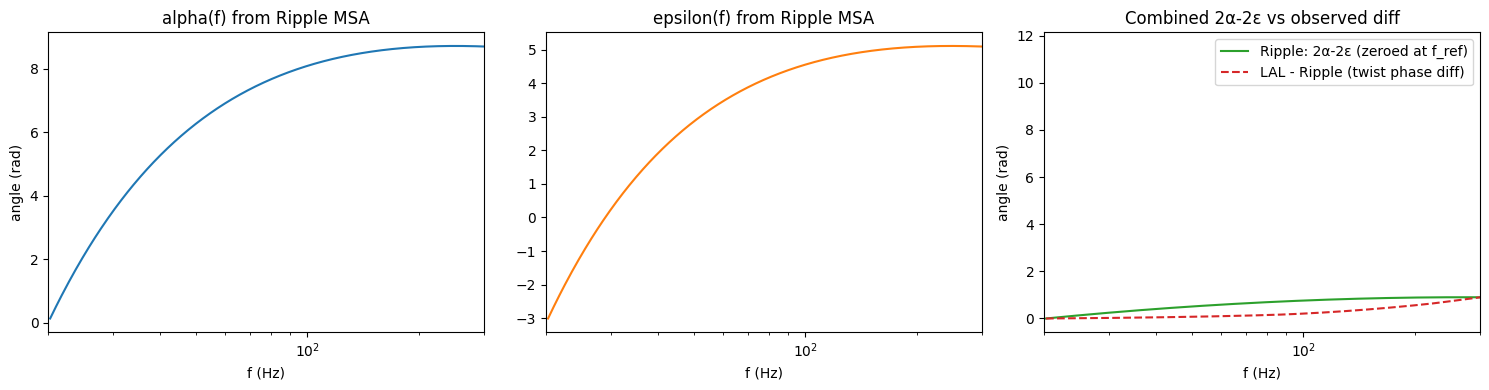

phiJ_Sf=0.0000, kappa=3.1416
alpha(f_ref)=0.1316, eps(f_ref)=-3.0142
alpha(50Hz)=6.2592, eps(50Hz)=2.8590
alpha(100Hz)=8.0868, eps(100Hz)=4.5607


In [9]:

# Diagnostic 2: Extract Ripple's alpha and epsilon directly and plot them.
# Also compare the combined (2*alpha - 2*eps) against the twist phase extracted above.
from ripplegw.waveforms import LALSimIMRPhenomX_precession as pPrec_mod
from ripplegw.conversions import Mc_eta_to_ms

m1_v, m2_v = Mc_eta_to_ms((mc, eta))
Mf_diag = (m1_v + m2_v) * f * MTSUN

eta_v = float(eta)
s1x_v, s1y_v, s1z_v = s1x, s1y, s1z
s2x_v, s2y_v, s2z_v = s2x, s2y, s2z

orbital_angular_momentum = pPrec_mod.flag_222_223_twoPN_non_spinning_orbitan_angular_momentum(
    eta_v, eta_v**2, s1z_v, s2z_v, (m1_v - m2_v)/(m1_v + m2_v), np.pi**2
)
Msec_v = (m1_v + m2_v) * MTSUN
piM_v = np.pi * Msec_v
v_ref_v = (piM_v * f_ref)**(1/3)
LRef_v = pPrec_mod.XLALSimIMRPhenomXLPNAnsatz(
    v_ref_v, eta_v / v_ref_v, *orbital_angular_momentum
)

theta_JN_v, Nz_Jf_v, Nx_Jf_v, phiJ_Sf_v, kappa_v, zeta_pol_v = pPrec_mod.compute_thetaJN_kappa_and_zeta(
    m1_v/(m1_v+m2_v), m2_v/(m1_v+m2_v),
    s1x_v, s1y_v, s1z_v, s2x_v, s2y_v, s2z_v,
    LRef_v, phi_ref, inclination
)
msa_setup_v = pPrec_mod.compute_msa_precession_setup(
    m1_v, m2_v, s1x_v, s1y_v, s1z_v, s2x_v, s2y_v, s2z_v, f_ref, kappa_v, phiJ_Sf_v
)

alpha_arr, eps_arr, cos_beta_arr = pPrec_mod.compute_evolved_spin_given_setup(Mf_diag, 2, msa_setup_v)
alpha_np = np.array(alpha_arr)
eps_np = np.array(eps_arr)

# The leading contribution to the twist phase for face-on is 2*alpha - 2*eps
combined_angle = 2*alpha_np - 2*eps_np
# Zero at f_ref
combined_angle -= combined_angle[i_ref]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(f, alpha_np, label='alpha'); axs[0].set_xlabel('f (Hz)'); axs[0].set_ylabel('angle (rad)')
axs[0].set_title('alpha(f) from Ripple MSA'); axs[0].set_xscale('log'); axs[0].set_xlim([20,300])

axs[1].plot(f, eps_np, label='epsilon', color='C1'); axs[1].set_xlabel('f (Hz)')
axs[1].set_title('epsilon(f) from Ripple MSA'); axs[1].set_xscale('log'); axs[1].set_xlim([20,300])

axs[2].plot(f, combined_angle, label='Ripple: 2α-2ε (zeroed at f_ref)', color='C2')
axs[2].plot(f, diff, label='LAL - Ripple (twist phase diff)', color='C3', ls='--')
axs[2].set_xlabel('f (Hz)'); axs[2].set_ylabel('angle (rad)')
axs[2].set_title('Combined 2α-2ε vs observed diff'); axs[2].set_xscale('log'); axs[2].set_xlim([20,300])
axs[2].legend()
plt.tight_layout()
plt.show()

print(f"phiJ_Sf={float(phiJ_Sf_v):.4f}, kappa={float(kappa_v):.4f}")
print(f"alpha(f_ref)={alpha_np[i_ref]:.4f}, eps(f_ref)={eps_np[i_ref]:.4f}")
print(f"alpha(50Hz)={alpha_np[i_50]:.4f}, eps(50Hz)={eps_np[i_50]:.4f}")
print(f"alpha(100Hz)={alpha_np[i_100]:.4f}, eps(100Hz)={eps_np[i_100]:.4f}")


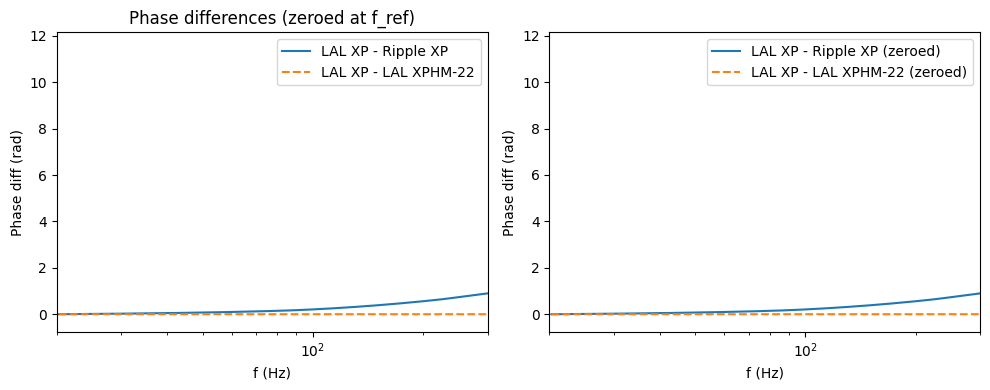

LAL XP - LAL XPHM-22 at f=50 Hz:  0.000000 rad
LAL XP - LAL XPHM-22 at f=100 Hz: 0.000000 rad
LAL XP - LAL XPHM-22 at f=200 Hz: 0.000000 rad


In [10]:

# Diagnostic 3: Generate LAL XPHM-22 to check if LAL XPHM also has the tc offset vs LAL XP.
# If LAL XPHM-22 == LAL XP, the offset is in Ripple's MSA; if LAL XPHM-22 != LAL XP,
# it's a fundamental model difference between how XP uses XAS vs XPHM uses XHM modes.

def get_lal_XPHM_22only(f, theta, f_ref):
    m1_kg = float(theta[0]) * lal.MSUN_SI
    m2_kg = float(theta[1]) * lal.MSUN_SI
    s1x, s1y, s1z_l = float(theta[2]), float(theta[3]), float(theta[4])
    s2x, s2y, s2z_l = float(theta[5]), float(theta[6]), float(theta[7])
    distance = float(theta[8]) * 1e6 * lal.PC_SI
    phi_ref_l = float(theta[10])
    inclination_l = float(theta[11])
    f_l = float(f[0]); f_u = float(f[-1]); df = float(f[1] - f[0])

    approx_xphm = lalsim.SimInspiralGetApproximantFromString("IMRPhenomXPHM")
    p = lal.CreateDict()
    lalsim.SimInspiralWaveformParamsInsertPhenomXPrecVersion(p, 222)
    # Request only 22 mode
    ma = lalsim.SimInspiralCreateModeArray()
    lalsim.SimInspiralModeArrayActivateMode(ma, 2, 2)
    lalsim.SimInspiralModeArrayActivateMode(ma, 2, -2)
    lalsim.SimInspiralWaveformParamsInsertModeArray(p, ma)

    hp_full, hc_full = lalsim.SimInspiralChooseFDWaveform(
        m1_kg, m2_kg, s1x, s1y, s1z_l, s2x, s2y, s2z_l,
        distance, inclination_l, phi_ref_l, 0, 0, 0,
        df, f_l, f_u, float(f_ref), p, approx_xphm
    )
    hp_full, hc_full = hp_full.data.data, hc_full.data.data
    freqs_lal = np.arange(len(hp_full)) * df
    mask = (freqs_lal >= f_l) & (freqs_lal <= f_u)
    return hp_full[mask], hc_full[mask]

hp_lal_xphm22, hc_lal_xphm22 = get_lal_XPHM_22only(np.array(f), theta_lal, f_ref)

phase_lal_xphm22 = np.unwrap(np.angle(hp_lal_xphm22))
diff_lal_lal = lal_phase - phase_lal_xphm22  # LAL XP - LAL XPHM-22
diff_lal_lal -= diff_lal_lal[i_ref]  # zero at f_ref

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(f, lal_phase - ripple_phase, label='LAL XP - Ripple XP')
axs[0].plot(f, diff_lal_lal, label='LAL XP - LAL XPHM-22', ls='--')
axs[0].set_xlabel('f (Hz)'); axs[0].set_ylabel('Phase diff (rad)')
axs[0].set_xscale('log'); axs[0].legend(); axs[0].set_xlim([20,300])
axs[0].set_title('Phase differences (zeroed at f_ref)')

axs[1].plot(f, lal_phase - ripple_phase - (lal_phase - ripple_phase)[i_ref], label='LAL XP - Ripple XP (zeroed)')
axs[1].plot(f, diff_lal_lal, label='LAL XP - LAL XPHM-22 (zeroed)', ls='--')
axs[1].set_xlabel('f (Hz)'); axs[1].set_ylabel('Phase diff (rad)')
axs[1].set_xscale('log'); axs[1].legend(); axs[1].set_xlim([20,300])
plt.tight_layout()
plt.show()

print(f"LAL XP - LAL XPHM-22 at f=50 Hz:  {diff_lal_lal[i_50]:.6f} rad")
print(f"LAL XP - LAL XPHM-22 at f=100 Hz: {diff_lal_lal[i_100]:.6f} rad")
print(f"LAL XP - LAL XPHM-22 at f=200 Hz: {diff_lal_lal[i_200]:.6f} rad")


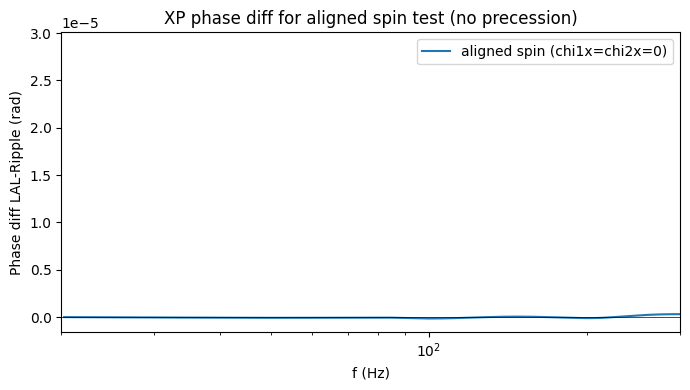

Aligned-spin phase diff at f=50 Hz:  -0.000000 rad
Aligned-spin phase diff at f=100 Hz: -0.000000 rad
Aligned-spin phase diff at f=200 Hz: -0.000000 rad
(If ~0 everywhere, MSA evolution is the source; non-zero → bug elsewhere)


In [11]:

# Diagnostic 4: Test with aligned spin (chi1x=chi2x=0) — MSA angles should be trivial (constant).
# Any residual tc offset for aligned spins would implicate something OTHER than MSA.
# If the offset vanishes, the bug is definitely in the MSA angle evolution.

theta_ripple_aligned = jnp.array([mc, eta, 0.0, 0.0, s1z, 0.0, 0.0, s2z, distance, 0.0, phi_ref, inclination])
theta_lal_aligned    = jnp.array([m1, m2, 0.0, 0.0, s1z, 0.0, 0.0, s2z, distance, 0.0, phi_ref, inclination])

hp_rip_aln, _ = gen_IMRPhenomXP_hphc(f, theta_ripple_aligned, f_ref)
hp_lal_aln, _ = get_lal_XP(np.array(f), theta_lal_aligned, f_ref)

phase_rip_aln = np.unwrap(np.angle(np.array(hp_rip_aln)))
phase_lal_aln = np.unwrap(np.array(np.angle(hp_lal_aln)))
diff_aln = phase_lal_aln - phase_rip_aln
diff_aln -= diff_aln[i_ref]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(f, diff_aln, label='aligned spin (chi1x=chi2x=0)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('f (Hz)'); ax.set_ylabel('Phase diff LAL-Ripple (rad)')
ax.set_xscale('log'); ax.legend(); ax.set_xlim([20, 300])
ax.set_title('XP phase diff for aligned spin test (no precession)')
plt.tight_layout(); plt.show()

print(f"Aligned-spin phase diff at f=50 Hz:  {diff_aln[i_50]:.6f} rad")
print(f"Aligned-spin phase diff at f=100 Hz: {diff_aln[i_100]:.6f} rad")
print(f"Aligned-spin phase diff at f=200 Hz: {diff_aln[i_200]:.6f} rad")
print("(If ~0 everywhere, MSA evolution is the source; non-zero → bug elsewhere)")
